In [1]:
!nvidia-smi # Check Colab GPU T4 availability and status

Mon Mar 23 18:57:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ==========================================
# 1. HN_Adam
# ==========================================

# Clone GitHub repository into Colab's temporary storage
!git clone https://github.com/jlariola/HN_Adam.git

# Change the Colab working directory to the newly downloaded folder
%cd HN_Adam

# Import HN_Adam
from hn_adam_tf import HN_Adam

Cloning into 'HN_Adam'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 30 (delta 12), reused 27 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 6.09 KiB | 6.09 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/HN_Adam


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

In [4]:
# ==========================================
# 2. Dataset Preparation
# ==========================================
print("\nLoading and splitting MNIST dataset...")
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

# Combine all data to properly split into exactly 40k / 10k / 10k 
x_all = np.concatenate([x_train_full, x_test], axis=0)
y_all = np.concatenate([y_train_full, y_test], axis=0)

# Preprocessing: convert to float32 and size-normalize to range 0-1
x_all = np.expand_dims(x_all, -1).astype("float32") / 255.0

# Split datasets
x_train, y_train = x_all[:40000], y_all[:40000]
x_val, y_val = x_all[40000:50000], y_all[40000:50000]
x_test, y_test = x_all[50000:60000], y_all[50000:60000]

print(f"Train set: {x_train.shape[0]} | Val set: {x_val.shape[0]} | Test set: {x_test.shape[0]}\n")


Loading and splitting MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train set: 40000 | Val set: 10000 | Test set: 10000



In [5]:
# ==========================================
# 3. Network Architecture (Deep CNN)
# ==========================================
def build_model():
    inputs = layers.Input(shape=(28, 28, 1))
    
    # First Block
    x = layers.Conv2D(32, (3, 3), padding='valid')(inputs)
    x = layers.Conv2D(32, (3, 3), padding='valid')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Activation('relu')(x)
    
    # Second Block
    x = layers.Conv2D(64, (3, 3), padding='valid')(x)
    x = layers.Conv2D(64, (3, 3), padding='valid')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Activation('relu')(x)
    
    # Flatten
    x = layers.Flatten()(x)
    
    # Fully Connected Layers
    x = layers.Dense(512)(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Dense(128)(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Dense(256)(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Dense(32)(x)
    x = layers.Activation('relu')(x)
    
    # Dropout Layer
    x = layers.Dropout(0.1)(x)
    
    # Output Layer
    outputs = layers.Dense(10, activation='softmax')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# Verify Architecture
model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 697,034 (2.66 MB)

 Trainable params: 697,034 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ==========================================
# 4. Benchmarking Loop Setup
# ==========================================
epochs = 50
batch_size = 128
learning_rate = 0.001
beta_1 = 0.9
beta_2 = 0.99
epsilon = 1e-8

optimizers_dict = {
    'HN_Adam': lambda: HN_Adam(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2, epsilon=epsilon),
    'Adam': lambda: tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2, epsilon=epsilon),
    'SGD': lambda: tf.keras.optimizers.SGD(learning_rate=learning_rate),
    'AMSGrad': lambda: tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2, epsilon=epsilon, amsgrad=True)
}

results = {
    opt: {'loss': [], 'acc': [], 'train_time': 0.0, 'min_loss': float('inf'), 'test_acc': 0.0} 
    for opt in optimizers_dict.keys()
}

In [10]:
# ==========================================
# 5. Training Phase
# ==========================================
for opt_name, opt_constructor in optimizers_dict.items():
    print(f"\n--- Initializing Training for {opt_name} ---")
    model = build_model()
    optimizer = opt_constructor()
    
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    start_time = time.time()
    
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        batch_size=batch_size,
        epochs=epochs,
        verbose=1
    )
    
    end_time = time.time()
    
    # Log Metrics
    results[opt_name]['train_time'] = end_time - start_time
    results[opt_name]['loss'] = history.history['loss']
    results[opt_name]['acc'] = history.history['accuracy']
    results[opt_name]['min_loss'] = min(history.history['loss'])
    
    # Final Evaluation on Testing Set
    print(f"Evaluating {opt_name} on Test Dataset...")
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results[opt_name]['test_acc'] = test_acc


--- Initializing Training for HN_Adam ---
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.1003 - loss: nan - val_accuracy: 0.0972 - val_loss: nan
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1004 - loss: nan - val_accuracy: 0.0972 - val_loss: nan
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1004 - loss: nan - val_accuracy: 0.0972 - val_loss: nan
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1004 - loss: nan - val_accuracy: 0.0972 - val_loss: nan
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1004 - loss: nan - val_accuracy: 0.0972 - val_loss: nan
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1004 - loss: nan - val_accuracy: 0.0972 - val_loss: nan
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1004 - loss: nan - val_accuracy: 0.0972 - val_loss: nan
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1004 - loss: nan - val_accuracy: 0.

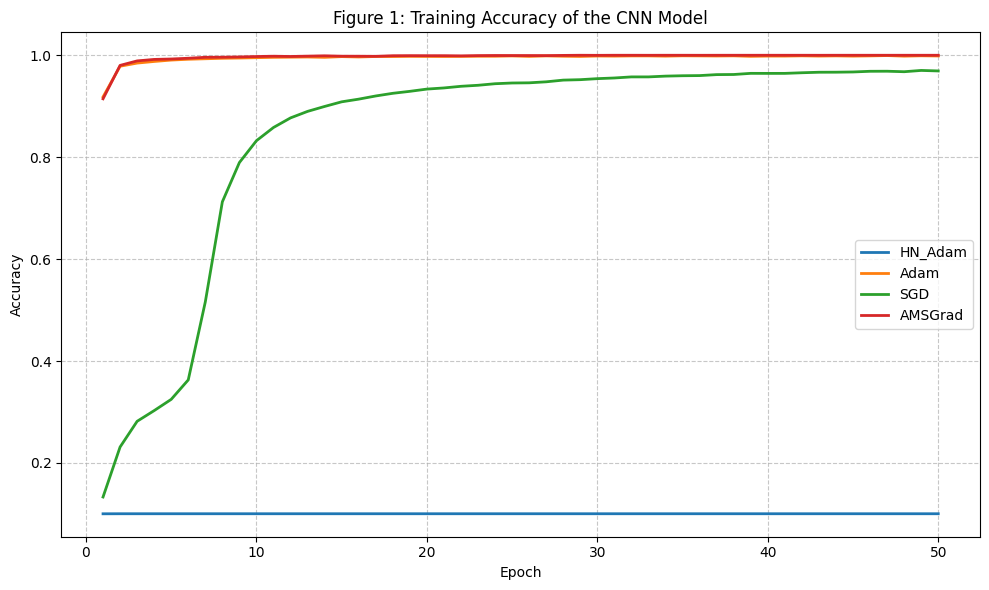

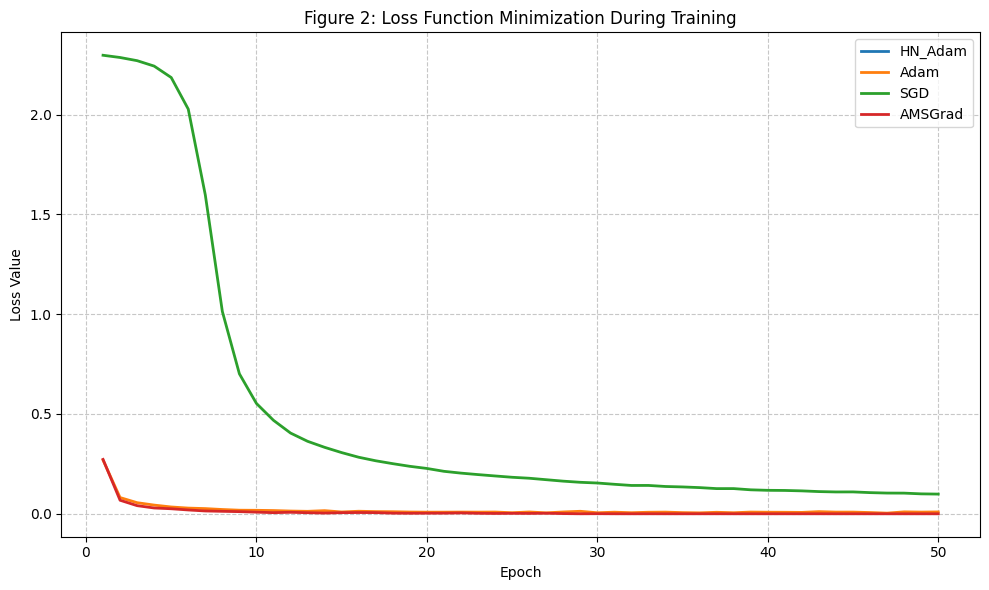


Table 1: Accuracy Results and Training Time Comparison
Algorithm Min_Training_Loss Testing_Accuracy Training_Time (Seconds)
  HN_Adam               nan            9.61%                   122 s
     Adam          0.003308           99.19%                   118 s
      SGD          0.098698           97.43%                   109 s
  AMSGrad          0.000011           99.31%                   119 s


In [11]:
# ==========================================
# 6. Final Output (Figures & Table)
# ==========================================

# Figure 1: Accuracy Curves During Training
plt.figure(figsize=(10, 6))
for opt_name in optimizers_dict.keys():
    plt.plot(range(1, epochs + 1), results[opt_name]['acc'], label=opt_name, linewidth=2)
plt.title('Figure 1: Training Accuracy of the CNN Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Figure 2: Loss Function Curves During Training
plt.figure(figsize=(10, 6))
for opt_name in optimizers_dict.keys():
    plt.plot(range(1, epochs + 1), results[opt_name]['loss'], label=opt_name, linewidth=2)
plt.title('Figure 2: Loss Function Minimization During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Table 1: Performance Metrics
table_data = {
    'Algorithm': list(optimizers_dict.keys()),
    'Min_Training_Loss': [f"{results[opt]['min_loss']:.6f}" for opt in optimizers_dict.keys()],
    'Testing_Accuracy': [f"{results[opt]['test_acc'] * 100:.2f}%" for opt in optimizers_dict.keys()],
    'Training_Time (Seconds)': [f"{int(results[opt]['train_time'])} s" for opt in optimizers_dict.keys()]
}

table1 = pd.DataFrame(table_data)
print("\nTable 1: Accuracy Results and Training Time Comparison")
print("=" * 75)
print(table1.to_string(index=False))
print("=" * 75)